# Lab 5: Stochastic Gradient Descent

**Student: Viktoriia Vlasenko, 2088928**

In [126]:
import numpy as np

import matplotlib.pyplot as plt

rnd_state = np.random.RandomState(121212)

Let us consider the following optimization problem
$$
x^* \arg\min\limits_{x \in \mathbb{R}^d} F(x) := \mathbb{E}_Z[f(x, Z)].
$$
Furthermore, let us assume that the gradient $\nabla f(x)$ is not computable or is too expensive to compute. In this scenario, we cannot use gradient descent (or GD is too expensive). Alternatively, we can consider the following iteration known as Stochastic Gradient Descent (SGD)
$$
x_{k + 1} = x_k - \gamma_k \nabla f(x_k, z_k)
$$
where $z_k$ is a realization of the random variable $Z_k$.

The above model includes the following finite sum setting
$$
F(x) = \frac{1}{d} \sum_{i=1}^d f_i (x)
$$


# Exercise 1

For illustration purposes, let us consider the following example:
$$
\arg\min\limits_{x \in \mathbb{R}^d} F(x) := \frac{1}{d}\sum_{j=1}^d \frac{1}{2}(a_j^T x)^2 = \frac{1}{2d} \|Ax\|^2
$$
with $d = 20$, $x \in \mathbb{R}^{d}$ and $A \in \mathbb{R}^{d \times d}$, and where we define $f_j(x) = \frac{1}{2}(a_j^T x)^2$ for $j=1,\dots,d$.

We observe that the minimum value of the function is $0$, attained at $x^*=(0,\dots,0)^T$.

In [127]:
d = 20
A = rnd_state.randn(d, d)

def F(x):
  return  np.linalg.norm(A.dot(x), ord=2) ** 2 / (2*d)


Let us implement the gradient $\nabla F$ and the stochastic gradient $\nabla f$ through the two functions `grad_F(x)` and `grad_f(x, z)`



In [128]:
def grad_F(x):
  # TODO: return the gradient of F at x
  return (A.T @ A @ x) / d

def grad_f(x, z):
  # In this case the realization z is an index of A.
  a = A[z, :] # let a be the row of A at index z
  # TODO: return the stochastic gradient at x, z
  return a * (a.dot(x))

Let us now define the function `gd(x0, gamma, max_iter)`.
The function takes in input $x_0 \in \mathbb{R}^{d}$, a stepsize $\gamma$ and a maximum number of iteration $\text{max\_iter} > 0$ and performs Gradient Descent. The function returns $x_\text{max\_iter}$ and the sequence $x_k$.

In [129]:
def gd(x0, gamma, max_iter):
  x = x0.copy()
  x_iters = np.empty((max_iter + 1, x0.shape[0]))
  f_vals = np.empty((max_iter + 1))
  x_iters[0] = x0.copy()
  f_vals[0] = F(x0)
  for k in range(1, max_iter + 1):

    # TODO: implement the Gradient Descent iteration
    x = x - gamma * grad_F(x)

    x_iters[k] = x.copy()
    f_vals[k] = F(x)
  return x, x_iters, f_vals

Similarly, let us implement SGD with the function `sgd(x0, gamma, alpha, T)`.
The function takes in input $x_0 \in \mathbb{R}^{d}$, two constant values $\gamma >0$ and $\alpha > 0$, a maximum number of iteration $\text{max\_iter} > 0$ and performs Gradient Descent. The function returns $x_\text{max\_iter}$ and the sequence $x_k$.

The step-size is implemented directly in the function as
$$
\gamma_k := \gamma k^{-\alpha}
$$
___
Hint: to generate random integers see
- [np.random.randint](https://numpy.org/doc/stable/reference/random/generated/numpy.random.randint.html)
- [np.random.choice](https://numpy.org/doc/stable/reference/random/generated/numpy.random.choice.html)


In [130]:
#To compare in a fair way with GD, we have to do d*max_iter iterations of SGD
#We will store the iterates and function values only at the end of each epoch (i.e., every d iterations).
def sgd(x0, gamma, alpha, max_iter):
  x = x0.copy()
  x_iters = np.empty((max_iter + 1, x0.shape[0]))
  f_vals = np.empty((max_iter + 1))
  x_iters[0] = x0.copy()
  f_vals[0] = F(x0)
  for k in range(1, d*max_iter + 1):

    # TODO: sample a random index
    z = rnd_state.randint(d)

    # TODO: implement the Stochastic Gradient Descent iteration
    gamma_k = gamma * (k**(-alpha))
    x  = x - gamma_k * grad_f(x, z)

    # Store the iterate and function value at the end of each epoch
    if k % d == 0:
      x_iters[k//d] = x.copy()
      f_vals[k//d] = F(x)
  return x, x_iters, f_vals

Let us run the GD algorithm and SGD with fixed step size that is $\alpha=0$ (this is the finite horizon setting)

In [131]:
x0 = np.ones(d)

# TODO: fix the step size as 1/L
L = np.linalg.norm(A, ord=2)**2 / d
gamma = 1/L

max_iter = 5000

# TODO: run the GD algorithm
x_gd, iters_gd, fvals_gd = gd(x0, gamma, max_iter)


# TODO: run the SGD algorithm
alpha = 0
x_sgd, iters_sgd, fvals_sgd = sgd(x0, gamma, alpha, max_iter)

/tmp/ipykernel_4468/3529070891.py:9: RuntimeWarning: overflow encountered in multiply
  return a * (a.dot(x))


Let us plot the sequence $\| x_k - x^* \|$

<>:10: SyntaxWarning: invalid escape sequence '\|'
<>:10: SyntaxWarning: invalid escape sequence '\|'
/tmp/ipykernel_4468/1796203230.py:10: SyntaxWarning: invalid escape sequence '\|'
  ax.set_ylabel("$\|x_k - x^*\|$", fontsize=16)


Text(0, 0.5, '$\\|x_k - x^*\\|$')

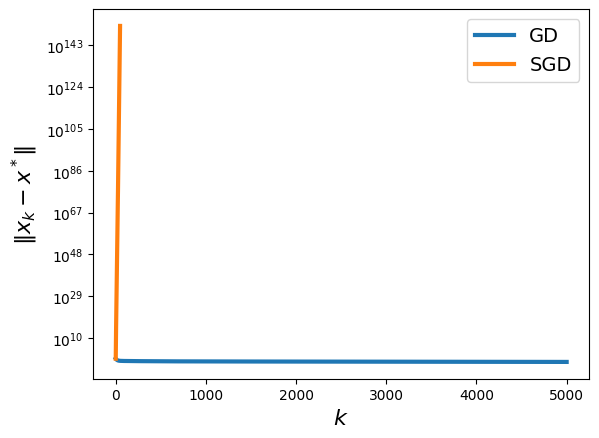

In [132]:
gd_norm = np.linalg.norm(iters_gd, axis=1, ord=2)
sgd_norm = np.linalg.norm(iters_sgd, axis=1, ord=2)

fig, ax = plt.subplots()
ax.plot(range(len(gd_norm)),  gd_norm, '-', lw=3, label="GD")
ax.plot(range(len(sgd_norm)),sgd_norm, '-', lw=3, label="SGD")
ax.legend(fontsize=14)
ax.set_yscale("log")
ax.set_xlabel("$k$", fontsize=16)
ax.set_ylabel("$\|x_k - x^*\|$", fontsize=16)

Let us plot the values of the target function $F(x_k)$.

Text(0, 0.5, '$F(x_k)$')

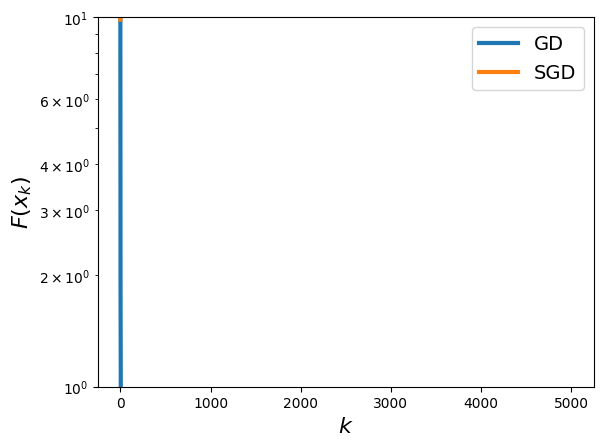

In [133]:
fig, ax = plt.subplots(1, 1)
ax.plot(range(len(fvals_gd)),  fvals_gd, '-' ,lw=3, label="GD")
ax.plot(range(len(fvals_sgd)), fvals_sgd, '-',lw=3, label="SGD")
ax.legend(fontsize=14)
ax.set_yscale("log")
ax.set_xlabel("$k$", fontsize=16)
ax.set_ylabel("$F(x_k)$", fontsize=16)

### Tuning the step-size in the infinite horizon setting

Fix $\alpha = \frac{1}{2}$ and define a list of values for $\gamma$.

In [134]:
x0 = np.ones(d)
max_iter = 5000
values = []
norms = []
alpha = 1/2

# TODO: define a list of gamma
gammas = [0.01, 0.05, 0.1, 0.2, 0.3, 0.5, 1.0]


for (i, gamma) in enumerate(gammas):
  # TODO: run the SGD algorithm
  x_sgd, iters_sgd, fvals_sgd = sgd(x0, gamma, alpha, max_iter)

  values.append(fvals_sgd)
  norms.append(np.linalg.norm(iters_sgd, axis=1, ord=2))

Let us plot the results

<>:4: SyntaxWarning: invalid escape sequence '\g'
<>:5: SyntaxWarning: invalid escape sequence '\g'
<>:9: SyntaxWarning: invalid escape sequence '\|'
<>:4: SyntaxWarning: invalid escape sequence '\g'
<>:5: SyntaxWarning: invalid escape sequence '\g'
<>:9: SyntaxWarning: invalid escape sequence '\|'
/tmp/ipykernel_4468/3624885912.py:4: SyntaxWarning: invalid escape sequence '\g'
  ax1.plot(values[i], '-', lw=3, label='$\gamma = {:.4f}$'.format(gammas[i]))
/tmp/ipykernel_4468/3624885912.py:5: SyntaxWarning: invalid escape sequence '\g'
  ax2.plot( norms[i], '-', lw=3, label='$\gamma = {:.4f}$'.format(gammas[i]))
/tmp/ipykernel_4468/3624885912.py:9: SyntaxWarning: invalid escape sequence '\|'
  ax2.set_ylabel("$\|x_k - x^*\|$"  ,fontsize=14)


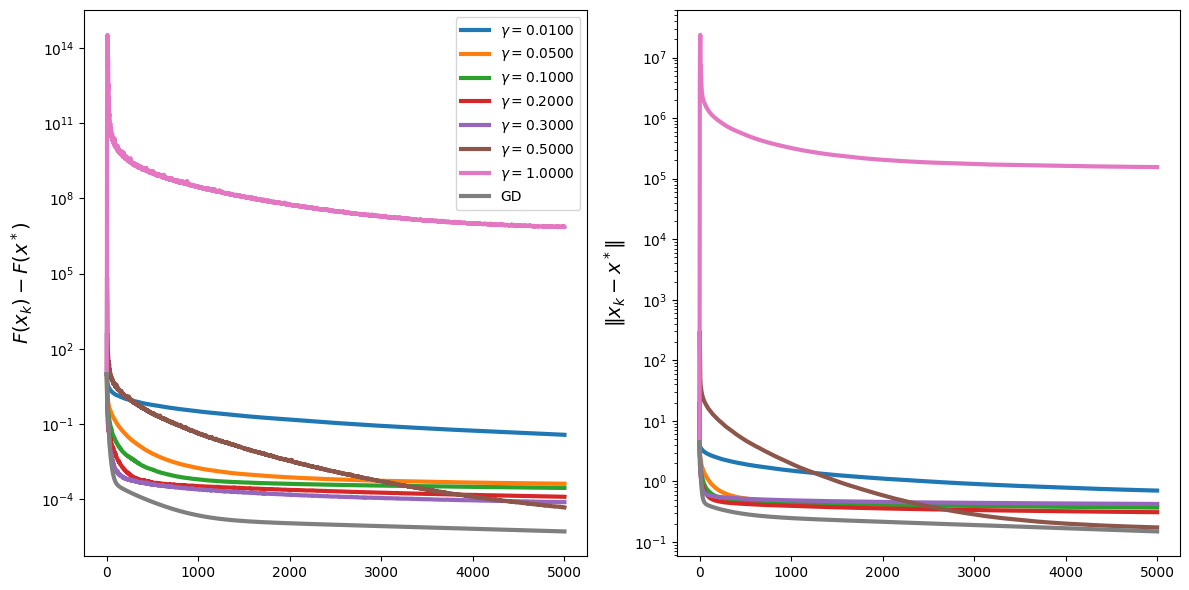

In [135]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))

for i in range(len(values)):
  ax1.plot(values[i], '-', lw=3, label='$\gamma = {:.4f}$'.format(gammas[i]))
  ax2.plot( norms[i], '-', lw=3, label='$\gamma = {:.4f}$'.format(gammas[i]))
ax1.plot(fvals_gd, '-', lw=3, label='GD')
ax2.plot( gd_norm, '-', lw=3, label='GD')
ax1.set_ylabel("$F(x_k) - F(x^*)$",fontsize=14)
ax2.set_ylabel("$\|x_k - x^*\|$"  ,fontsize=14)
ax1.set_yscale("log")
ax2.set_yscale("log")
ax1.legend()
fig.tight_layout()

Let us repeat the experiment with defining a list of gammas and alphas (including $\gamma=\frac{1}{L}$ and $\alpha=0$)

In [136]:
x0 = np.ones(d)
max_iter = 5000
values = []
norms = []

# Calculate L from previous context if not already available
L = np.linalg.norm(A, ord=2)**2 / d
print(L)

# TODO: define a list of gamma
gammas = [0.01, 0.05, 0.1, 0.2, 0.3, 0.5, 1.0, 1/L]

# TODO: define a list of alpha
alphas = [0, 0.01, 0.05, 0.1, 0.2, 0.3, 0.5, 1.05]

for alpha, gamma in zip(alphas, gammas):
    # TODO: run the SGD algorithm
    x_sgd, iters_sgd, fvals_sgd = sgd(x0, gamma, alpha, max_iter)

    values.append(fvals_sgd)
    norms.append(np.linalg.norm(iters_sgd, axis=1))

3.8341304497632565


Let us plot the results

<>:9: SyntaxWarning: invalid escape sequence '\|'
<>:9: SyntaxWarning: invalid escape sequence '\|'
/tmp/ipykernel_4468/4024839837.py:9: SyntaxWarning: invalid escape sequence '\|'
  ax2.set_ylabel("$\|x_k - x^*\|$"  ,fontsize=14)


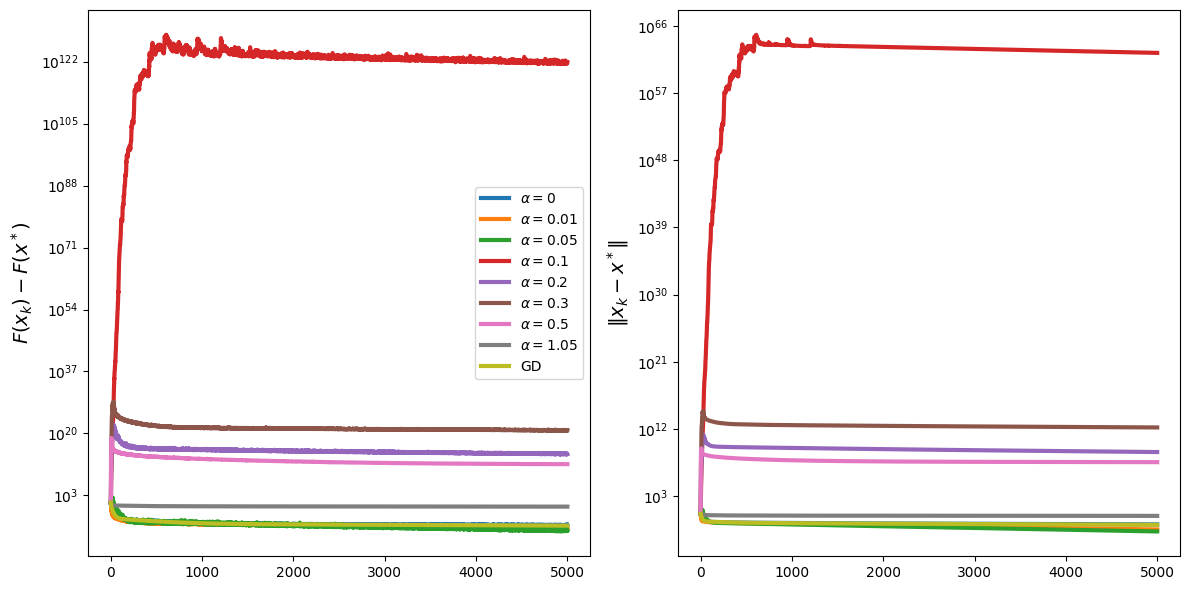

In [137]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))

for i in range(len(alphas)):
  ax1.plot(values[i], '-', lw=3, label='$\\alpha = {}$'.format(alphas[i]))
  ax2.plot( norms[i], '-', lw=3, label='$\\alpha = {}$'.format(alphas[i]))
ax1.plot(fvals_gd, '-', lw=3, label='GD')
ax2.plot( gd_norm, '-', lw=3, label='GD')
ax1.set_ylabel("$F(x_k) - F(x^*)$",fontsize=14)
ax2.set_ylabel("$\|x_k - x^*\|$"  ,fontsize=14)
ax1.set_yscale("log")
ax2.set_yscale("log")
ax1.legend()
fig.tight_layout()

### Mini-batch Gradient Descent
An alternative to Stochastic gradient descent is Mini-batch Gradient Descent (MBGD).

This algorithm consists in computing the gradient using random data batches instead of just one point as in SGD.

This provides a trade-off between the efficiency of SGD and the stability of GD. However, this adds the batch size as an additional parameter to tune.



Let us implement this algorithm through the function `mbgd(x0, gamma, alpha, batch_size, max_iter)`

In [138]:
#To compare in a fair way with GD, we have to do (d / batch_size)*max_iter iterations of MBGD
#We will store the iterates and function values only at the end of each epoch
def mbgd(x0, gamma, alpha, batch_size, max_iter):
  x = x0.copy()
  x_iters = np.empty((max_iter + 1, x0.shape[0]))
  f_vals = np.empty((max_iter + 1))
  x_iters[0] = x0.copy()
  f_vals[0] = F(x0)
  mult = d // batch_size
  for k in range(1, mult * (max_iter + 1)):

    # TODO: choose batch_size random indices without replacement (hint: see np.random.choice)
    batch_indices = rnd_state.choice(d, size=batch_size, replace=False)
    X_batch = A[batch_indices, :]

    # TODO: compute the gradient using the previously sampled batch
    nabla_f = 1/batch_size * X_batch.T @ (X_batch @ x)

    # TODO: implement the Stochastic Gradient Descent iteration
    gamma_k = gamma * (k**(-alpha))
    x  = x - gamma_k * nabla_f

    # Store the iterate and function value at the end of each epoch
    if k % mult == 0:
      x_iters[k // mult] = x.copy()
      f_vals[k // mult] = F(x)
  return x, x_iters, f_vals


Fixing `batch_size = 10`, let us run MBGD and compare the result with the other algorithms

In [139]:
x0 = np.ones(d)
batch_size = 10
alpha = 1/2
max_iter = 5000

# TODO: fix 1/L as stepsize
L = np.linalg.norm(A, ord=2)**2 / d
gamma = 1/L

# TODO: run GD
x_gd, iters_gd, fvals_gd = gd(x0, gamma, max_iter)
# TODO: run SGD
x_sgd, iters_sgd, fvals_sgd = sgd(x0, gamma, alpha, max_iter)
# TODO: run MBGD
x_mbgd, iters_mbgd, fvals_mbgd = mbgd(x0, gamma, alpha, batch_size, max_iter)

Let us plot the result

Text(0, 0.5, '$F(x_k)$')

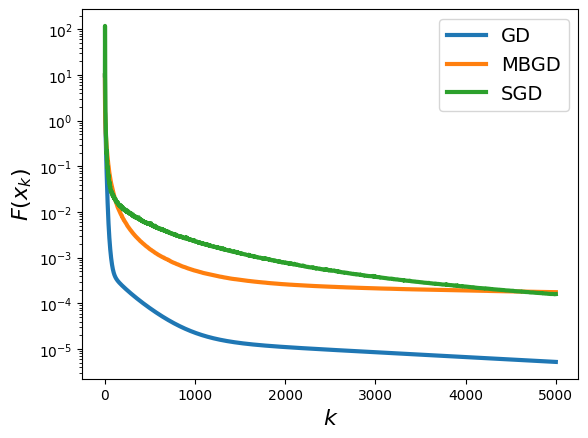

In [140]:
fig, ax = plt.subplots(1, 1)
ax.plot(range(len(fvals_gd)),  fvals_gd, '-' ,lw=3, label="GD")
ax.plot(range(len(fvals_mbgd)),  fvals_mbgd, '-' ,lw=3, label="MBGD")
ax.plot(range(len(fvals_sgd)), fvals_sgd, '-',lw=3, label="SGD")
ax.legend(fontsize=14)
ax.set_yscale("log")
ax.set_xlabel("$k$", fontsize=16)
ax.set_ylabel("$F(x_k)$", fontsize=16)

Fix $\alpha = 0$ and $\gamma$ to a reasonable value. Define a list of batch size values and observe the result

In [143]:
x0 = np.ones(d)
max_iter = 5000

alpha = 0
# TODO: fix 1/L as stepsize
L = np.linalg.norm(A, ord=2)**2 / d
gamma = 1/L

values = []
norms = []

# TODO: define a list of batch sizes such that they divide max_iter
batch_sizes = [10, 50, 75]


# TODO: run GD
x_gd, iters_gd, fvals_gd = gd(x0, gamma, max_iter)
gd_norm = np.linalg.norm(iters_gd, axis=1, ord=2)

for (i, bs) in enumerate(batch_sizes):
  # TODO: run MBGD
  x_mbgd, iters_mbgd, fvals_mbgd = mbgd(x0, gamma, alpha, bs, max_iter)

  values.append(fvals_mbgd)
  norms.append(np.linalg.norm(iters_mbgd, axis=1, ord=2))


<>:10: SyntaxWarning: invalid escape sequence '\|'
<>:10: SyntaxWarning: invalid escape sequence '\|'
/tmp/ipykernel_4468/1404343554.py:10: SyntaxWarning: invalid escape sequence '\|'
  ax2.set_ylabel("$\|x_k - x^*\|$"  ,fontsize=14)


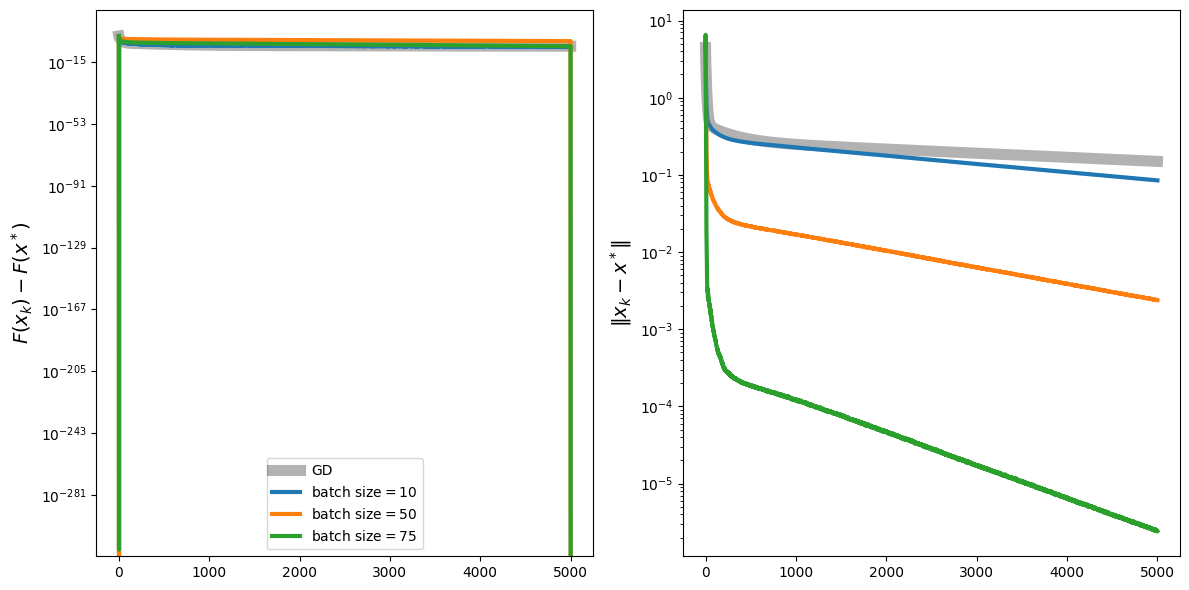

In [144]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))

ax1.plot(fvals_gd, '-', lw=8, alpha=0.3, c='black', label='GD')
ax2.plot(gd_norm, '-', lw=8, alpha=0.3, c='black', label='GD')

for i in range(len(batch_sizes)):
  ax1.plot(values[i], '-', lw=3, label='batch size$ = {}$'.format(batch_sizes[i]))
  ax2.plot( norms[i], '-', lw=3, label='batch size$ = {}$'.format(batch_sizes[i]))
ax1.set_ylabel("$F(x_k) - F(x^*)$",fontsize=14)
ax2.set_ylabel("$\|x_k - x^*\|$"  ,fontsize=14)
ax1.set_yscale("log")
ax2.set_yscale("log")
ax1.legend()
fig.tight_layout()

# Exercise 2

We consider an inverse problem
\begin{equation*}
 b = A \bar{x} + \varepsilon,
\end{equation*}
where $\bar{x}\in\mathbb{R}^m$ is an unknown signal, $b \in \mathbb{R}^n$ is a measurement,  $\varepsilon \in \mathbb{R}^n$ is a Gaussian zero mean noise vector and
$A \in \mathbb{R}^{n\times m}$  models the acquisition process.
To recover a sparse approximation of $\bar{x}$ we use an $\ell^1$-regularization:
\begin{equation*}
    \min_{x \in \mathbb{R}^m} \underbrace{\frac{1}{2}\|A x-b\|^2}_{=:f(x)}
    + \lambda \sum_{i=1}^m | x_i|.
\end{equation*}

We set
\begin{equation*}
    A = \begin{bmatrix}
        A_{:1} \cdots A_{:m}
    \end{bmatrix}
    = \begin{bmatrix}
        A_{1:}^\top\\
        \vdots\\
        A_{n:}^\top
\end{bmatrix},
\end{equation*}
where $A_{:i} \in \R^n$  and $A_{j:} \in \R^m$
are the $i$-th column and the $j$-th row of $A$ respectively.

Moreover,  $\nabla_i f(x)= A_{:i}^\top (A x- b)$,
thus $L_i = \| A_{:i} \|^2$.
The soft thresholding operator is
\begin{equation*}
    \mathrm{soft}_{\gamma_i \lambda}(x_i) =
    \mathrm{sign}(x_i)\max\{|x_i|- \gamma_i\lambda, 0\} =
    \begin{cases}
        x_i-\gamma_i\lambda & \text{if } x>\gamma_i\lambda\\
        0 & \text{if } |x|\leq \gamma_i\lambda\\
        x_i+\gamma_i\lambda & \text{if } x<-\gamma_i\lambda.
    \end{cases}
\end{equation*}

In [145]:
rng = np.random.default_rng(42)

m = 500
n = 1000
s = 50

lam = 0.1

# sensing matrix
A = rng.standard_normal((n, m))

# sparse signal
xs = np.zeros(m)

# indices of the nonzero components
support = rng.choice(m, size=s, replace=False)

# nonzero values
xs[support] = np.sign(rng.standard_normal(s)) * (1 - 0.5 * rng.random(s))

# noise
sigma = 0.06
epsi = rng.standard_normal(n)

# observations
b = A @ xs + sigma * epsi

Let us implement the objective function and the thresholding operator

In [146]:
def F(x):
    # TODO: return the objective function
    return 0.5 * np.linalg.norm(A @ x - b)**2 + lam * np.sum(np.abs(x))

In [147]:
def soft(x, rho):
    # TODO: implement the soft-thresholding operator
    return np.sign(x) * np.maximum(np.abs(x) - rho, 0)

Let us implement the Proximal Gradient algorithm.

The function takes as input the sensing matrix A, the observation vector b, and the maximum number of iterations max_iter, and returns the iterates and function values at each iteration.


In [156]:
def PGA(A, b, max_iter):
    delta = 1/2
    gamma = 2 * delta / (np.linalg.norm(A) ** 2)
    x_iters = np.zeros((m, max_iter + 1))
    fvals = np.zeros(max_iter + 1)
    for k in range(max_iter):
        fvals[k] = F(x_iters[:, k])

        # TODO: implement the Proximal Gradient algorithm iteration
        x_iters[:, k + 1] = soft(x_iters[:, k] - gamma * A.T @ (A @ x_iters[:, k] - b), gamma * lam)

    fvals[-1] = F(x_iters[:, -1])
    return x_iters, fvals

### Parallel Random Coordinate Proximal Gradient algorithm

Let $\eta = \max_j \Vert A_{j:} \Vert_0$, where $\|\cdot\|_0\|$ counts the non zero components of the entry vector ($\eta$ accounts for the sparsity of the matrix $A$).
The Parallel Random Coordinate Proximal Gradient algorithm is
\begin{equation*}
    x^{k+1} = x^ k + \sum_{i=1}^m
    \varepsilon_i^k\big[ \mathrm{soft}_{\gamma_i \lambda}
    (x^k_i - \gamma_i \bm{a}^{i\top}(A x^k - b) ) - x^k_i \big] \bm{e}_i,
    \qquad \gamma_i< \frac{2}{\min\{\tau,\eta\} L_i},
\end{equation*}
where $\tau$ is the number of coordinates that are processed in parallel (this corrispondes essentially to the batch size).


Now, if we define $\bm{u}^k= Ax^k - b$,
then multiplying the above equation by $A$ and subtracting  $b$
by both terms we get
\begin{equation*}
    \bm{u}^{k+1} = \bm{u}^k +  \sum_{i=1}^m \varepsilon_i^k \big[ \mathrm{soft}_{\gamma_{i} \lambda}
    \big( x_{i}^k - \gamma_{i} {\bm{a}^{i}}^\top\bm{u}^k \big) - x^k_{i} \big] \bm{a}^{i}.
\end{equation*}
Summarizing, the algorithm can be written as follows.
Let $x_0 = 0$, $\bm{u}_0 = A x_0 - b = - b$.
Then, for every  $k \in \mathbb{N}$,
\begin{equation*}
    \begin{array}{l}
    \left\lfloor
    \begin{array}{l}
    \text{randomly choose a nonempty set of indexes $I_k \subset \{1,\dots, m\}$ with cardinality $\tau$,}\\
    \text{according to a uniform distribution},\\
    \text{for } i \in I_k\\
    \begin{array}{l}
    \left\lfloor
    \xi_i = \mathrm{soft}_{\gamma_{i} \lambda}
    \big( x_{i}^k - \gamma_{i} {\bm{a}^{i}}^\top\bm{u}^k \big) - x^k_{i}
    \right.
    \end{array}\\[2ex]
    x^{k+1} = x^k + \textstyle\sum_{i \in I_k}\xi_i \bm{e}_{i},\\
    \bm{u}^{k+1} = \bm{u}^k + \textstyle\sum_{i \in I_k} \xi_i \bm{a}^{i}.
    \end{array}
    \right.
    \end{array}
\end{equation*}

Let us implement the Parallel Random Coordinate Proximal Gradient algorithm

In [149]:
def PRC_PGA(A, b, tau, max_iter):
    delta = 1/2
    eta = np.max(np.sum(A != 0, axis=1))
    gamma = np.zeros(m)
    for i in range(m):
        gamma[i] = 2 * delta / (min(tau, eta) * np.sum(A[:, i] ** 2))
    x_iters = np.zeros((m, max_iter + 1))
    u_iters = np.zeros((n, max_iter + 1))
    u_iters[:, 0] = -b
    fvals = np.zeros(max_iter + 1)

    for k in range(max_iter):
        idx = np.random.permutation(m)[:tau]
        fvals[k] = F(x_iters[:, k])

        xk = x_iters[:, k]
        uk = u_iters[:, k]

        # TODO: implement the PRC-PGA iteration
        z = xk[idx] - gamma[idx] * (A[:, idx].T @ uk)
        x_new_idx = soft(z, gamma[idx] * lam)

        r = x_new_idx - xk[idx]

        x_iters[:, k + 1] = xk
        x_iters[idx, k + 1] = xk[idx] + r
        u_iters[:, k + 1] = uk + A[:, idx] @ r
    fvals[-1] = F(x_iters[:, -1])
    return x_iters, fvals

Compare the two algorithms for a fixed value of tau.

In [157]:
tau = 20

#To compare in a fair way with PGA, we have to do (m / tau)*max_iter iterations of PRC_PGA
max_iter_PGA = 500
# TODO: fix the number of iterations of PRC-PGA
max_iter_PRC_PGA = int((m / tau)*max_iter_PGA)

# TODO: run PGA and PRC-PGA
x_pga, fvals_pga = PGA(A, b, max_iter_PGA)
x_prc_pga, fvals_prc_pga = PRC_PGA(A, b, tau, max_iter_PRC_PGA)

Let us plot the results

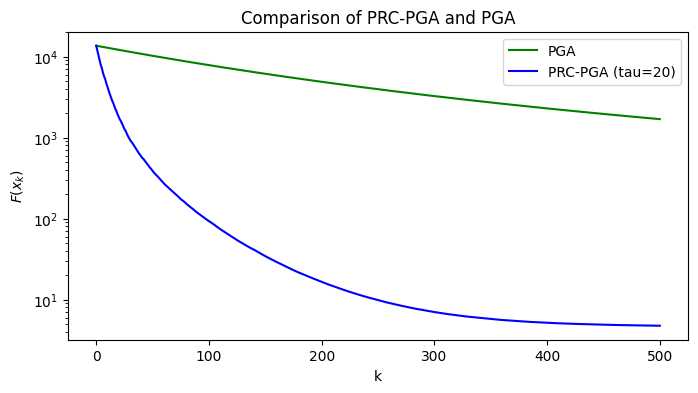

In [158]:
# Comparison of objective function values of PGA and PRC-PGA
plt.figure(figsize=(8, 4))
plt.plot(fvals_pga, label='PGA', color='g')
# Because PRC-PGA does (m / tau)*max_iter iterations, we need to subsample the function values to plot them against the number of epochs (i.e., every m/tau iterations)
plt.plot(fvals_prc_pga[::m // tau], label='PRC-PGA (tau={})'.format(tau), color='b')
plt.xlabel('k')
plt.ylabel('$F(x_k)$')
plt.title('Comparison of PRC-PGA and PGA')
plt.legend()
plt.yscale('log')
plt.show()

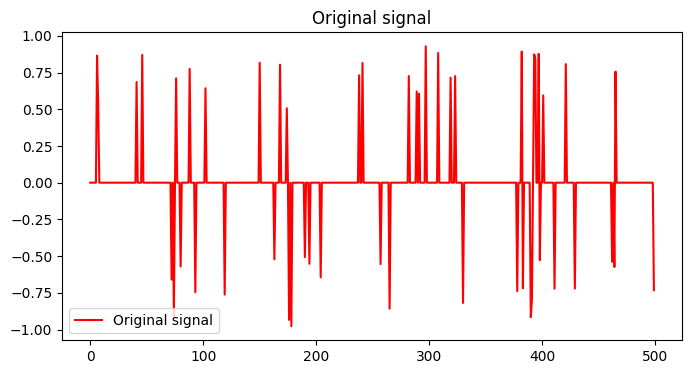

In [159]:
# Comparison of reconstructed signals of PGA and PRC-PGA
plt.figure(figsize=(8, 4))
plt.plot(xs, 'r', label='Original signal')
plt.title('Original signal')
plt.legend()
plt.show()

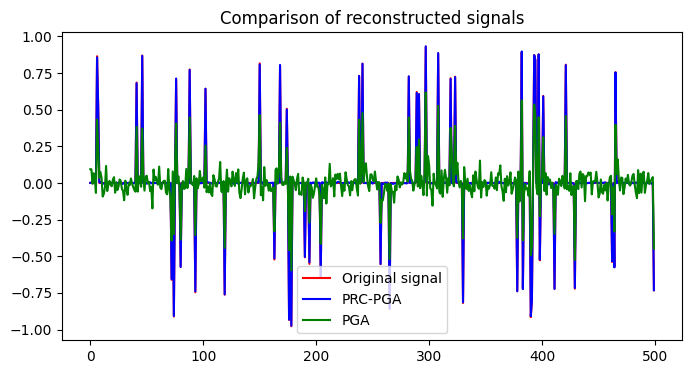

In [160]:
# Comparison of reconstructed signals of PGA and PRC-PGA
plt.figure(figsize=(8, 4))
plt.plot(xs, 'r', label='Original signal')
plt.plot(x_prc_pga[:, -1], 'b', label='PRC-PGA')
plt.plot(x_pga[:, -1], 'g', label='PGA')
plt.title('Comparison of reconstructed signals')
plt.legend()
plt.show()

Repeat the comparison with different values of tau

In [163]:
# List of tau values to test
taus = [1, 20, 50, 100]

results_prbc = {}

for tau in taus:
    # TODO: fix the number of iterations of PRC-PGA
    max_iter_PRBC_FBA = int((m / tau)*max_iter_PGA)

    # TODO: run PRBC-FBA
    x_prc_pga, fvals_prc_pga = PRC_PGA(A, b, tau, max_iter_PRBC_FBA)

    results_prbc[tau] = {'tau': tau,'fvals': fvals_prc_pga}

Let us plot the results

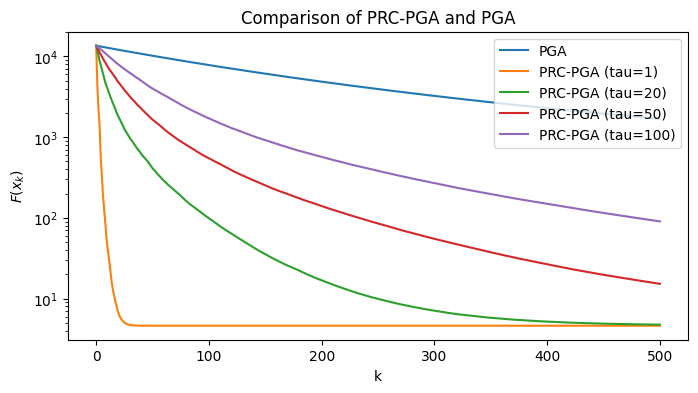

In [164]:
# Comparison of objective function values of PGA and PRC-PGA
plt.figure(figsize=(8, 4))
plt.plot(fvals_pga,label='PGA')
for tau in taus:
    fvals_prc_pga = results_prbc[tau]['fvals']
    plt.plot(fvals_prc_pga[::m // tau],label=f'PRC-PGA (tau={tau})')
plt.xlabel('k')
plt.ylabel('$F(x_k)$')
plt.title('Comparison of PRC-PGA and PGA')
plt.legend()
plt.yscale('log')
plt.show()